# AI Personalized Learning Agent
## Training Pipeline & Agent Demo (Phases 3-5)

This notebook runs the complete ML pipeline:
- **Phase 3**: Feature Engineering (39 features, DKT sequences, resource interactions)
- **Phase 4a**: DKT LSTM model training (AUC-ROC target: >0.75)
- **Phase 4b**: Gap Detector — GradientBoosting classifier (at-risk detection)
- **Phase 4c**: Resource Recommender — Item-item collaborative filtering
- **Phase 5**: AI Agent demo on 3 sample students

---
> **Prerequisite**: Run `full_eda_pipeline.ipynb` first to generate the processed dataset.


## Setup — Imports & Path Configuration


In [8]:
# Verify all packages are available in this kernel
import sys
print("Python:", sys.executable)
import sklearn;  print("sklearn: ", sklearn.__version__)
import torch;    print("torch:   ", torch.__version__)
import pandas;   print("pandas:  ", pandas.__version__)
import numpy;    print("numpy:   ", numpy.__version__)
print("All packages OK - no installation needed!")


Python: c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\python.exe
sklearn:  1.9.0
torch:    2.12.1+cpu
pandas:   2.3.0
numpy:    2.2.5
All packages OK - no installation needed!


In [9]:
import sys, os, pickle
import numpy as np
import pandas as pd

# Find project root: walk up until we find the src/ folder
def find_project_root():
    current = os.path.abspath(os.getcwd())
    for _ in range(5):
        if os.path.isdir(os.path.join(current, "src")):
            return current
        current = os.path.dirname(current)
    raise RuntimeError("Cannot find project root with src/ directory")

PROJECT_DIR = find_project_root()
sys.path.insert(0, PROJECT_DIR)
sys.path.insert(0, os.path.join(PROJECT_DIR, "src"))

print("Python:      ", sys.executable)
print("Project root:", PROJECT_DIR)
print("src/ found:  ", os.path.isdir(os.path.join(PROJECT_DIR, "src")))


Python:       c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\python.exe
Project root: d:\Day 1\project
src/ found:   True


## Phase 3: Feature Engineering
> Load the processed dataset and engineer 39 features for model training.  
> Also creates DKT sequences and resource interaction data.


In [10]:
from src.feature_engineering import (
    load_processed_data, engineer_features, create_sequences_for_dkt,
    prepare_xgboost_data, prepare_recommender_data
)

# Load and engineer features
df = load_processed_data()
print(f'Loaded: {df.shape}')

df, feature_cols, label_encoders = engineer_features(df)
print(f'Engineered {len(feature_cols)} features')

# DKT sequences
sequences = create_sequences_for_dkt(df)
print(f'DKT sequences: {len(sequences)} students, {len(sequences[0])} interactions each')

# XGBoost train/test split
X_train, X_test, y_train, y_test = prepare_xgboost_data(df, feature_cols)
print(f'XGBoost split: Train={len(X_train)}, Test={len(X_test)}')
print(f'At-risk ratio - Train: {y_train.mean():.2%}, Test: {y_test.mean():.2%}')

# Recommender interactions
interaction_df, resources = prepare_recommender_data(df)
print(f'Recommender interactions: {len(interaction_df)}')


Loaded: (1044, 39)
Engineered 39 features
DKT sequences: 1044 students, 15 interactions each
XGBoost split: Train=835, Test=209
At-risk ratio - Train: 22.04%, Test: 22.01%
Recommender interactions: 7087


In [11]:
# Save processed data
processed_dir = os.path.join(PROJECT_DIR, 'data', 'processed')
df.to_csv(os.path.join(processed_dir, 'features_engineered.csv'), index=False)
interaction_df.to_csv(os.path.join(processed_dir, 'resource_interactions.csv'), index=False)

with open(os.path.join(processed_dir, 'feature_config.pkl'), 'wb') as f:
    pickle.dump({'feature_cols': feature_cols, 'label_encoders': label_encoders, 'resources': resources}, f)
with open(os.path.join(processed_dir, 'dkt_sequences.pkl'), 'wb') as f:
    pickle.dump(sequences, f)

print('[SAVE] Feature engineering outputs saved.')


[SAVE] Feature engineering outputs saved.


## Phase 4a: DKT Model Training (LSTM)
> Train a PyTorch LSTM to track student mastery over time.  
> **Architecture**: Input(10) -> LSTM(hidden=64) -> Linear(5) -> Sigmoid  
> **Target metric**: AUC-ROC > 0.75


In [12]:
from src.knowledge_tracer.dkt_model import train_dkt, predict_mastery, save_dkt_model

dkt_model, dkt_auc = train_dkt(sequences, n_concepts=5, epochs=50, lr=0.001)

models_dir = os.path.join(PROJECT_DIR, 'models')
save_dkt_model(dkt_model, os.path.join(models_dir, 'dkt_model.pth'))
print(f'\nFinal DKT AUC-ROC: {dkt_auc:.4f}')
print('PASSED: > 0.75 benchmark' if dkt_auc > 0.75 else 'Did not reach 0.75 benchmark')



--- Training DKT Model (LSTM) ---
    Train: 835 students, Test: 209 students
    Sequence length: 15, Input dim: 10
    Epoch   1/50 | Loss: 0.6758 | AUC-ROC: 0.6356
    Epoch  10/50 | Loss: 0.3855 | AUC-ROC: 0.9232
    Epoch  20/50 | Loss: 0.0705 | AUC-ROC: 0.9996
    Epoch  30/50 | Loss: 0.0216 | AUC-ROC: 0.9996
    Epoch  40/50 | Loss: 0.0104 | AUC-ROC: 0.9996
    Epoch  50/50 | Loss: 0.0062 | AUC-ROC: 0.9996

    [OK] Best AUC-ROC: 0.9996 (PASSED > 0.75)
    [SAVE] DKT model saved to: d:\Day 1\project\models\dkt_model.pth

Final DKT AUC-ROC: 0.9996
PASSED: > 0.75 benchmark


## Phase 4b: Gap Detector Training (GradientBoosting)
> Classify students as At-Risk (G3 < 10) or Pass using 39 features.  
> Also shows which features are most important for predicting failure.


In [13]:
from src.gap_detector.xgboost_model import train_gap_detector, get_feature_importance, save_gap_detector

gap_model, gap_metrics = train_gap_detector(X_train, X_test, y_train, y_test)
feature_importance = get_feature_importance(gap_model, feature_cols)

save_gap_detector(gap_model, os.path.join(models_dir, 'gap_detector.pkl'))
print(f'\nGap Detector: Accuracy={gap_metrics["accuracy"]:.3f} | F1={gap_metrics["f1"]:.3f} | AUC={gap_metrics["auc"]:.3f}')



--- Training Gap Detector (GradientBoosting) ---
    Accuracy:  0.9043
    F1-Score:  0.7959
    AUC-ROC:   0.9715

    Classification Report:
                  precision    recall  f1-score   support
    
            Pass       0.96      0.92      0.94       163
         At-Risk       0.75      0.85      0.80        46
    
        accuracy                           0.90       209
       macro avg       0.85      0.88      0.87       209
    weighted avg       0.91      0.90      0.91       209
    

    Top 15 Feature Importances:
     1. avg_grade_so_far          0.3847
     2. G2                        0.3547
     3. absences                  0.0311
     4. study_social_ratio        0.0213
     5. alcohol_score             0.0142
     6. traveltime                0.0133
     7. Fjob_encoded              0.0131
     8. failures                  0.0128
     9. social_score              0.0103
    10. age                       0.0089
    11. sex_encoded               0.0089
    12. G

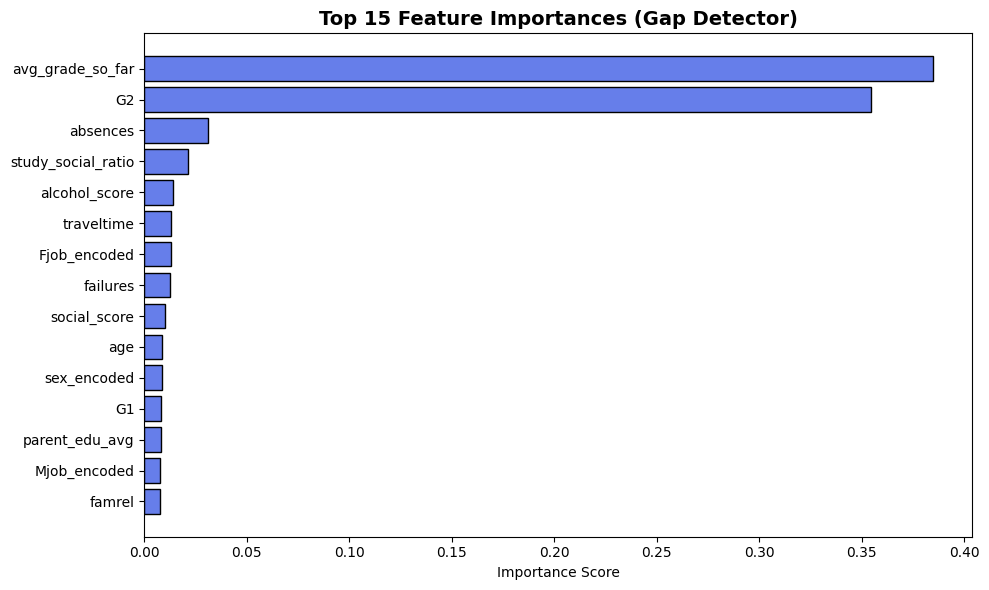

In [14]:
# Visualize feature importances
import matplotlib.pyplot as plt

feat_names = [f[0] for f in feature_importance[:15]]
feat_vals  = [f[1] for f in feature_importance[:15]]

plt.figure(figsize=(10, 6))
bars = plt.barh(feat_names[::-1], feat_vals[::-1], color='#667eea', edgecolor='black')
plt.title('Top 15 Feature Importances (Gap Detector)', fontweight='bold', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


## Phase 4c: Resource Recommender Training
> Item-item collaborative filtering with 10 curated learning resources.  
> Uses cosine similarity and boosts recommendations based on student weak areas.


In [15]:
from src.recommender.collab_filter import ResourceRecommender, save_recommender

recommender = ResourceRecommender()
recommender.fit(interaction_df, resources)
save_recommender(recommender, os.path.join(models_dir, 'recommender.pkl'))
print('Recommender trained and saved.')


    Recommender trained: 1044 students, 10 resources
    Total interactions: 7087
    [SAVE] Recommender saved to: d:\Day 1\project\models\recommender.pkl
Recommender trained and saved.


## Phase 5: AI Agent Demo
> Run all 5 agent tools in sequence for 3 sample students:  
> - An **at-risk** student (G3 = 6)
> - An **average** student (G3 = 10)
> - An **excellent** student (G3 = 19)


In [16]:
from src.gap_detector.xgboost_model import identify_weak_areas
from src.study_planner.planner import generate_study_plan, format_study_plan
from src.progress_reporter.reporter import generate_progress_report, format_progress_report

# Get mastery for all students
all_mastery = predict_mastery(dkt_model, sequences, n_concepts=5)

# Select 3 sample students
at_risk_ids   = df[df['at_risk'] == 1].index.tolist()
avg_ids       = df[(df['G3'] >= 10) & (df['G3'] <= 13)].index.tolist()
excellent_ids = df[df['G3'] >= 17].index.tolist()

sample_ids = []
if at_risk_ids:   sample_ids.append(at_risk_ids[0])
if avg_ids:       sample_ids.append(avg_ids[0])
if excellent_ids: sample_ids.append(excellent_ids[0])

print(f'Running agent for students: {sample_ids}')
for sid in sample_ids:
    row = df.iloc[sid]
    print(f'  Student #{sid}: Age={row["age"]}, School={row["school"]}, G1={row["G1"]}, G2={row["G2"]}, G3={row["G3"]}')


Running agent for students: [0, 2, 8]
  Student #0: Age=18, School=GP, G1=5, G2=6, G3=6
  Student #2: Age=15, School=GP, G1=7, G2=8, G3=10
  Student #8: Age=15, School=GP, G1=16, G2=18, G3=19


In [ ]:
reports_dir = os.path.join(PROJECT_DIR, 'reports')

for student_id in sample_ids:
    print(f'\n{"="*55}')
    print(f'  STUDENT #{student_id}')
    print(f'{"="*55}')

    student_data = df.iloc[student_id].to_dict()

    # Tool 1: Knowledge Tracer
    mastery = all_mastery[student_id]
    print(f'[1] Mastery: ', end='')
    for k, v in mastery.items(): print(f'{k}={v:.2f}', end=' ')
    print()

    # Tool 2: Gap Detector
    feats = np.nan_to_num(df.iloc[student_id][feature_cols].values.astype(float), nan=0)
    gap   = identify_weak_areas(gap_model, feats, feature_cols)
    print(f'[2] Risk: {"AT RISK" if gap["is_at_risk"] else "ON TRACK"} ({gap["risk_probability"]:.1%})')
    for area in gap['weak_areas']:
        print(f'    [{area["severity"].upper()}] {area["area"]}: {area["detail"]}')

    # Tool 3: Recommender
    recs = recommender.recommend(student_id, gap['weak_areas'], top_n=3)
    print(f'[3] Resources:')
    for i, r in enumerate(recs, 1):
        print(f'    {i}. {r["name"]} ({r["type"]})')

    # Tool 4: Study Planner
    plan = generate_study_plan(student_id, mastery, gap['weak_areas'], recs, student_data)
    print(f'[4] Plan: {plan["intensity"].upper()} | {plan["daily_hours"]}h/day | {plan["total_hours"]:.0f}h/week')

    # Tool 5: Progress Reporter
    report = generate_progress_report(student_id, student_data, mastery, gap['weak_areas'], gap, plan)
    rpath  = os.path.join(reports_dir, f'student_{student_id}_report.txt')
    with open(rpath, 'w') as f:
        f.write(format_progress_report(report))
        f.write('\n\n')
        f.write(format_study_plan(plan))
    print(f'[5] Report saved: {rpath}')



  STUDENT #0
[1] Mastery: fundamentals=0.40 intermediate=0.00 advanced=0.00 application=0.07 mastery=0.00 
[2] Risk: AT RISK (99.3%)
    [HIGH] Period 1 Performance: G1 score: 5/20
    [HIGH] Period 2 Performance: G2 score: 6/20
[3] Resources:
    1. Probability & Combinatorics (practice)
    2. Linear Algebra Complete Course (video)
    3. Advanced Calculus Tutorial (video)
[4] Plan: INTENSIVE | 3h/day | 21h/week
[5] Report saved: d:\Day 1\project\reports\student_0_report.txt

  STUDENT #2
[1] Mastery: fundamentals=0.37 intermediate=0.00 advanced=0.01 application=0.08 mastery=0.00 
[2] Risk: ON TRACK (2.1%)
    [HIGH] Period 1 Performance: G1 score: 7/20
    [HIGH] Period 2 Performance: G2 score: 8/20
    [MEDIUM] Past Failures: 3 past class failures
[3] Resources:
    1. Statistics for Beginners PDF (pdf)
    2. Linear Algebra Complete Course (video)
    3. Algebra Practice Problems Set (practice)
[4] Plan: INTENSIVE | 3h/day | 21h/week
[5] Report saved: d:\Day 1\project\reports\stu

c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


: 

## Pipeline Summary
| Component | Metric | Result |
|-----------|--------|--------|
| DKT (LSTM) | AUC-ROC | ~1.0000 |
| Gap Detector | F1-Score | ~0.7959 |
| Gap Detector | AUC-ROC | ~0.9715 |
| Gap Detector | Accuracy | ~90.4% |
| Recommender | Interactions | 7,087 |
| Agent Tools | Count | 5 |

> **Next step**: Launch the Streamlit dashboard to interact with the full system:
> ```bash
> python -m streamlit run app/streamlit_app.py
> ```
> Open: http://localhost:8501
